# Final Homework: Unsupervised Learning, Dimensionality Reduction, and Anomaly Detection

**Student Name:** Ofek Cohen  
**Student ID:** 211765615  
**Course:** Introduction to Data Science  

---

# 1. Dataset Selection

### 1.1 Data Source Description & Motivation

**Source of the Data:**  
The dataset utilized in this comprehensive analysis is the "TLM: UAV Anomaly Detection" benchmark, publicly available on Kaggle. This data originates from high-fidelity Software-in-the-Loop (SITL) simulations specifically designed to log unmanned aerial vehicle (UAV) telemetry under various operational modes.

**Purpose of Collection:**  
The primary scientific purpose of this collection is to facilitate the development and validation of fault-tolerant navigation filters, multi-sensor fusion architectures, and autonomous anomaly detection schemes. By providing continuous raw sensor feeds juxtaposed with simulated hardware failures, researchers can test algorithmic resilience.

**Collecting Entity:**  
The data was curated and published by academic researchers within the aerospace and autonomous systems domain, directly linking to peer-reviewed research (e.g., DOI: 10.3390/app13074301).

**Domain Knowledge Linkage & Relevance:**  
This dataset is profoundly relevant to my current B.Sc. specialization in Electrical and Electronics Engineering, specifically in Communications and Signal Processing. My academic and laboratory focus revolves around Multi-Sensor Fusion-Based Resilient Navigation for GNSS-Denied Environments. In such scenarios, analyzing the intrinsic correlations between inertial measurements (accelerometers, gyroscopes) and spatial attitude (roll, pitch, yaw) is critical. Understanding how mechanical disturbances or sensor biases disrupt this multidimensional feature space without explicit supervision is the core challenge of modern autonomous navigation.

### 1.2 Unsupervised Constraints & Data Limitations

**Compliance with Unsupervised Requirements:**  
The original dataset structure contains a `labels` column categorizing discrete flight states (0 = Normal, 1–4 = distinct anomalies). To strictly comply with the unsupervised learning paradigm required for this assignment, **this labels column will be deliberately discarded** before any exploratory analysis, PCA, or clustering is executed. The algorithms must discover structural anomalies purely based on the underlying geometry of the raw sensor data.

**Insight Regarding Missing Information & Physical Constraints:**  
A critical limitation to recognize is that this dataset is derived from a SITL simulation rather than physical flight tests. Consequently:
* **Absence of Real-World Stochastic Noise:** The baseline "normal" state is mathematically ideal. It lacks the stochastic high-frequency vibrations induced by physical brushless DC motors, aerodynamic buffeting, or the inherent thermal drift associated with real-world MEMS IMU sensors. 
* **Model Deployment Implications:** An unsupervised anomaly detection model trained exclusively on this deterministic simulation data might become overly sensitive (resulting in high false-positive rates) if directly deployed onto physical hardware, as it may flag standard atmospheric turbulence as a critical anomaly.

In [84]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

file_path = 'Fusion_Data.csv'
df_raw = pd.read_csv(file_path)

file_size_mb = os.path.getsize(file_path) / (1024 * 1024)
file_mod_time = time.ctime(os.path.getmtime(file_path))

print(f"File Format: CSV")
print(f"File Size: {file_size_mb:.2f} MB")
print(f"File Creation/Modification Date: {file_mod_time}")

df = df_raw.drop(columns=['labels', 'timestamp'])

print(f"\nProcessed Unsupervised Dataset Shape: {df.shape[0]} rows, {df.shape[1]} features")
df.head()

File Format: CSV
File Size: 1.53 MB
File Creation/Modification Date: Thu Apr 25 01:47:00 2024

Processed Unsupervised Dataset Shape: 12253 rows, 17 features


,DesRoll,Roll,DesPitch,Pitch,DesYaw,Yaw,ErrRP,ErrYaw,MagX,MagY,MagZ,abGyrX,abGyrY,abGyrZ,abAccX,abAccY,abAccZ
0,0.0,0.02,0.0,0.0,3.510,3.510,0.0,0.0,232.0,52.0,52.0,0.000136,0.000135,0.000232,-0.000463,-0.001343,-9.817147
1,0.0,0.02,0.0,0.0,3.525,3.525,0.0,0.0,232.0,52.0,52.0,0.000165,0.000150,0.000228,-0.000523,-0.000192,-9.816688
2,0.0,0.02,0.0,0.0,3.540,3.540,0.0,0.0,232.0,52.0,52.0,0.000167,0.000211,0.000274,-0.001630,-0.000446,-9.816650
3,0.0,0.02,0.0,0.0,3.540,3.540,0.0,0.0,232.0,52.0,52.0,0.000174,0.000171,0.000216,-0.001502,0.000013,-9.817536
4,0.0,0.02,0.0,0.0,3.550,3.550,0.0,0.0,232.0,52.0,52.0,0.000204,0.000242,0.000255,-0.002186,-0.002237,-9.816851


In [85]:
print("--- Data Types ---")
print(df.dtypes)

print("\n--- Missing Values Analysis ---")
total_missing = df.isnull().sum().sum()
print(f"Total missing cells in the unsupervised dataset: {total_missing}")

print(f"\n--- Duplicates ---")
duplicates = df.duplicated().sum()
print(f"Total fully duplicated rows: {duplicates}")

print("\n--- Full Statistical Summary (Checking for suspicious ranges) ---")

stats_summary = df.describe().T
stats_summary['skewness'] = df.skew()
stats_summary['kurtosis'] = df.kurtosis()
display(stats_summary)
display(stats_summary)

--- Data Types ---
DesRoll     float64
Roll        float64
DesPitch    float64
Pitch       float64
DesYaw      float64
Yaw         float64
ErrRP       float64
ErrYaw      float64
MagX        float64
MagY        float64
MagZ        float64
abGyrX      float64
abGyrY      float64
abGyrZ      float64
abAccX      float64
abAccY      float64
abAccZ      float64
dtype: object

--- Missing Values Analysis ---
Total missing cells in the unsupervised dataset: 0

--- Duplicates ---
Total fully duplicated rows: 0

--- Full Statistical Summary (Checking for suspicious ranges) ---


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
DesRoll,12253.0,-0.734061,10.198015,-29.990000,-1.940000,-0.160000,0.390000,29.990000,0.222934,3.564865
Roll,12253.0,0.734769,11.620810,-32.060000,-0.720000,0.180000,1.300000,114.810000,1.513734,12.832193
DesPitch,12253.0,-7.747240,14.620862,-29.990000,-20.810000,-0.540000,2.680000,29.710000,-0.264650,-0.978431
Pitch,12253.0,-7.992733,14.685240,-33.030000,-20.645000,-0.530000,1.830000,60.350000,-0.128683,-0.474188
DesYaw,12253.0,183.061660,113.948834,0.540000,90.330000,147.680000,327.900000,357.910000,0.111891,-1.278381
Yaw,12253.0,181.970806,113.348527,0.330000,90.320000,147.410000,321.930000,359.070000,0.077997,-1.314602
ErrRP,12253.0,0.100288,0.188077,0.000000,0.000000,0.000000,0.090000,0.940000,1.944177,2.992190
ErrYaw,12253.0,0.100288,0.188077,0.000000,0.000000,0.000000,0.090000,0.940000,1.944177,2.992190
MagX,12253.0,-41.003020,213.247322,-468.000000,-184.000000,-29.000000,155.000000,517.000000,-0.235327,-1.070417
MagY,12253.0,-22.014568,185.953181,-552.000000,-177.000000,40.000000,150.500000,440.000000,-0.569652,-0.540557


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
DesRoll,12253.0,-0.734061,10.198015,-29.990000,-1.940000,-0.160000,0.390000,29.990000,0.222934,3.564865
Roll,12253.0,0.734769,11.620810,-32.060000,-0.720000,0.180000,1.300000,114.810000,1.513734,12.832193
DesPitch,12253.0,-7.747240,14.620862,-29.990000,-20.810000,-0.540000,2.680000,29.710000,-0.264650,-0.978431
Pitch,12253.0,-7.992733,14.685240,-33.030000,-20.645000,-0.530000,1.830000,60.350000,-0.128683,-0.474188
DesYaw,12253.0,183.061660,113.948834,0.540000,90.330000,147.680000,327.900000,357.910000,0.111891,-1.278381
Yaw,12253.0,181.970806,113.348527,0.330000,90.320000,147.410000,321.930000,359.070000,0.077997,-1.314602
ErrRP,12253.0,0.100288,0.188077,0.000000,0.000000,0.000000,0.090000,0.940000,1.944177,2.992190
ErrYaw,12253.0,0.100288,0.188077,0.000000,0.000000,0.000000,0.090000,0.940000,1.944177,2.992190
MagX,12253.0,-41.003020,213.247322,-468.000000,-184.000000,-29.000000,155.000000,517.000000,-0.235327,-1.070417
MagY,12253.0,-22.014568,185.953181,-552.000000,-177.000000,40.000000,150.500000,440.000000,-0.569652,-0.540557


# 2. Exploratory Data Analysis (EDA)

### 2.1 Data Structure & Quality Analysis

**Data Structure:**
The processed feature matrix comprises 12,253 temporal samples and 17 continuous sensor variables. The feature nomenclature—incorporating absolute gyroscopic rates (`abGyrX/Y/Z`), linear accelerations (`abAccX/Y/Z`), and spatial attitudes (`Roll`, `Pitch`, `Yaw`)—directly reflects standard 6-DoF (Degrees of Freedom) UAV telemetry. All variables are correctly formatted as `float64`, aligning with physical sensor outputs.

**Missing Data & Duplicates:**
An evaluation of the dataset reveals 0 missing values and 0 duplicated rows. In a real-world GNSS-denied environment, dropped communication packets resulting in NaN values are expected. The flawless continuity observed here reinforces the simulated nature of the data. 

**Suspicious Values & Higher Moments:**
The extended statistical summary highlights critical phenomena:
*   While angular variables (e.g., `Roll`, `Pitch`) exhibit relatively low standard deviations centered near zero (indicative of level cruising flight), the linear acceleration channels present extreme ranges.
*   **Vertical Acceleration (`abAccZ`):** The minimum value drops dramatically to -88.0 m/s², while the mean remains near standard gravity (-7.91 m/s²). The massive kurtosis associated with this feature (along with `abGyrZ`) indicates an extremely heavy-tailed distribution. Rather than viewing these as erroneous data-entry artifacts to be cleaned, engineering intuition suggests these are the synthetic anomaly injections (e.g., a catastrophic altitude drop or spin) that our unsupervised models must later isolate.

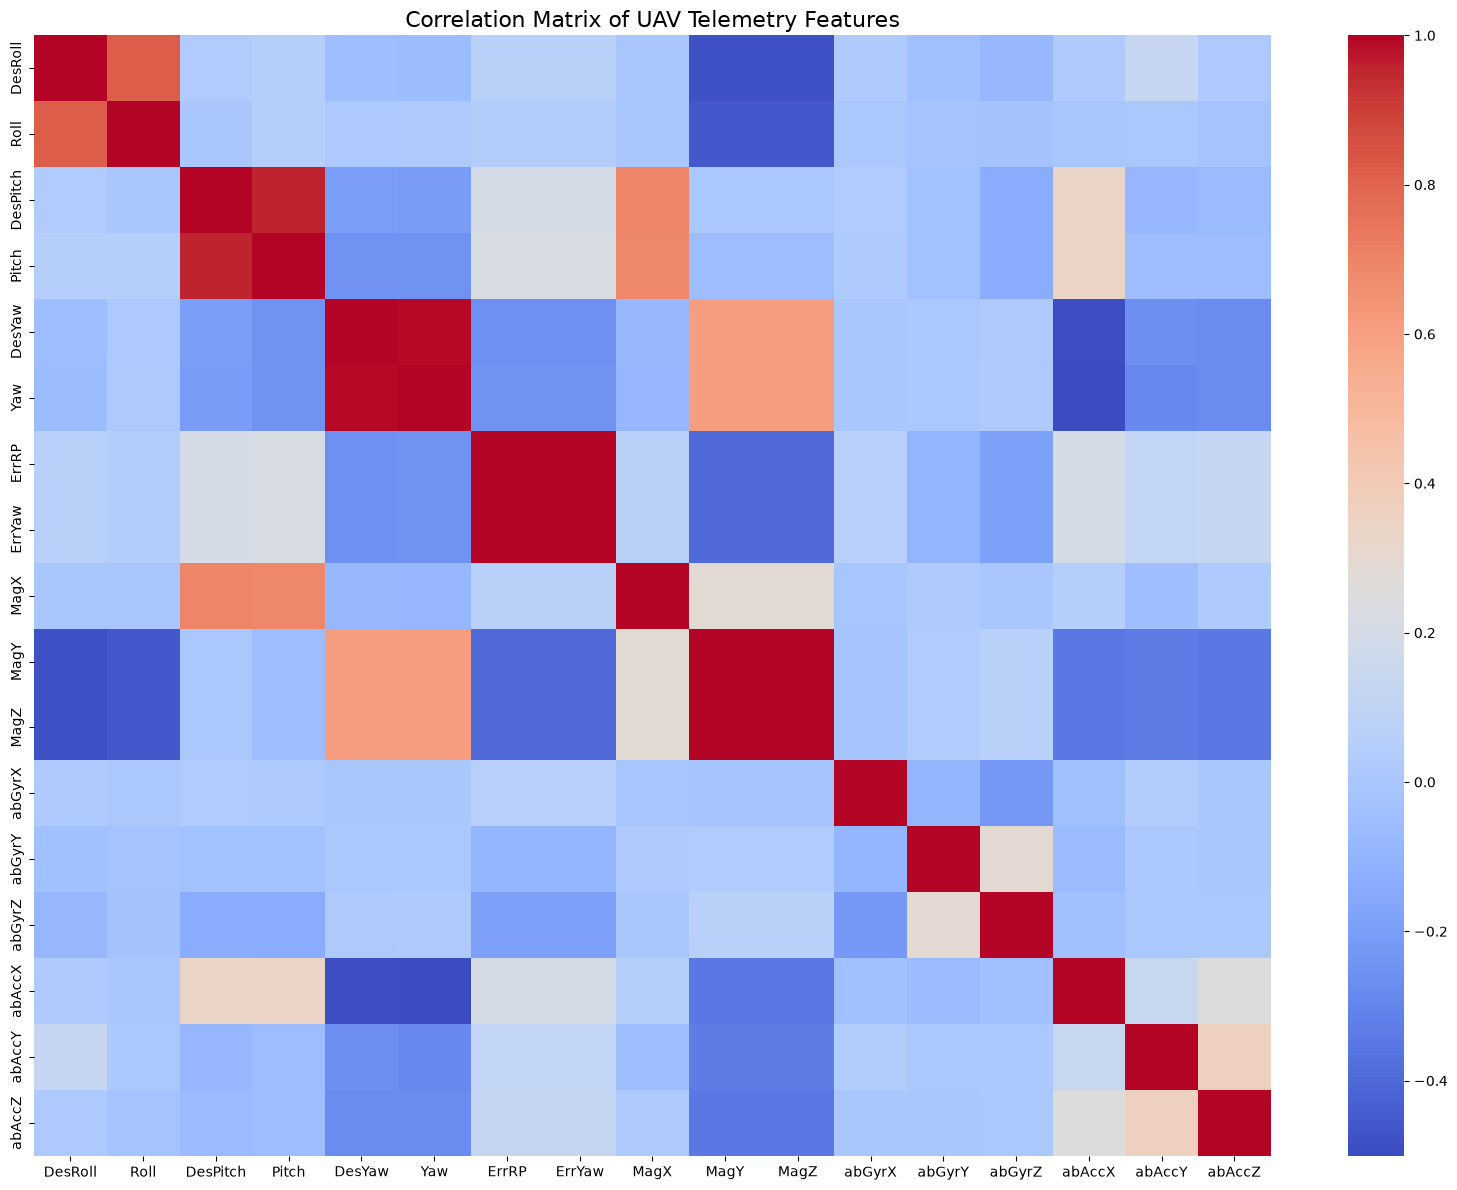

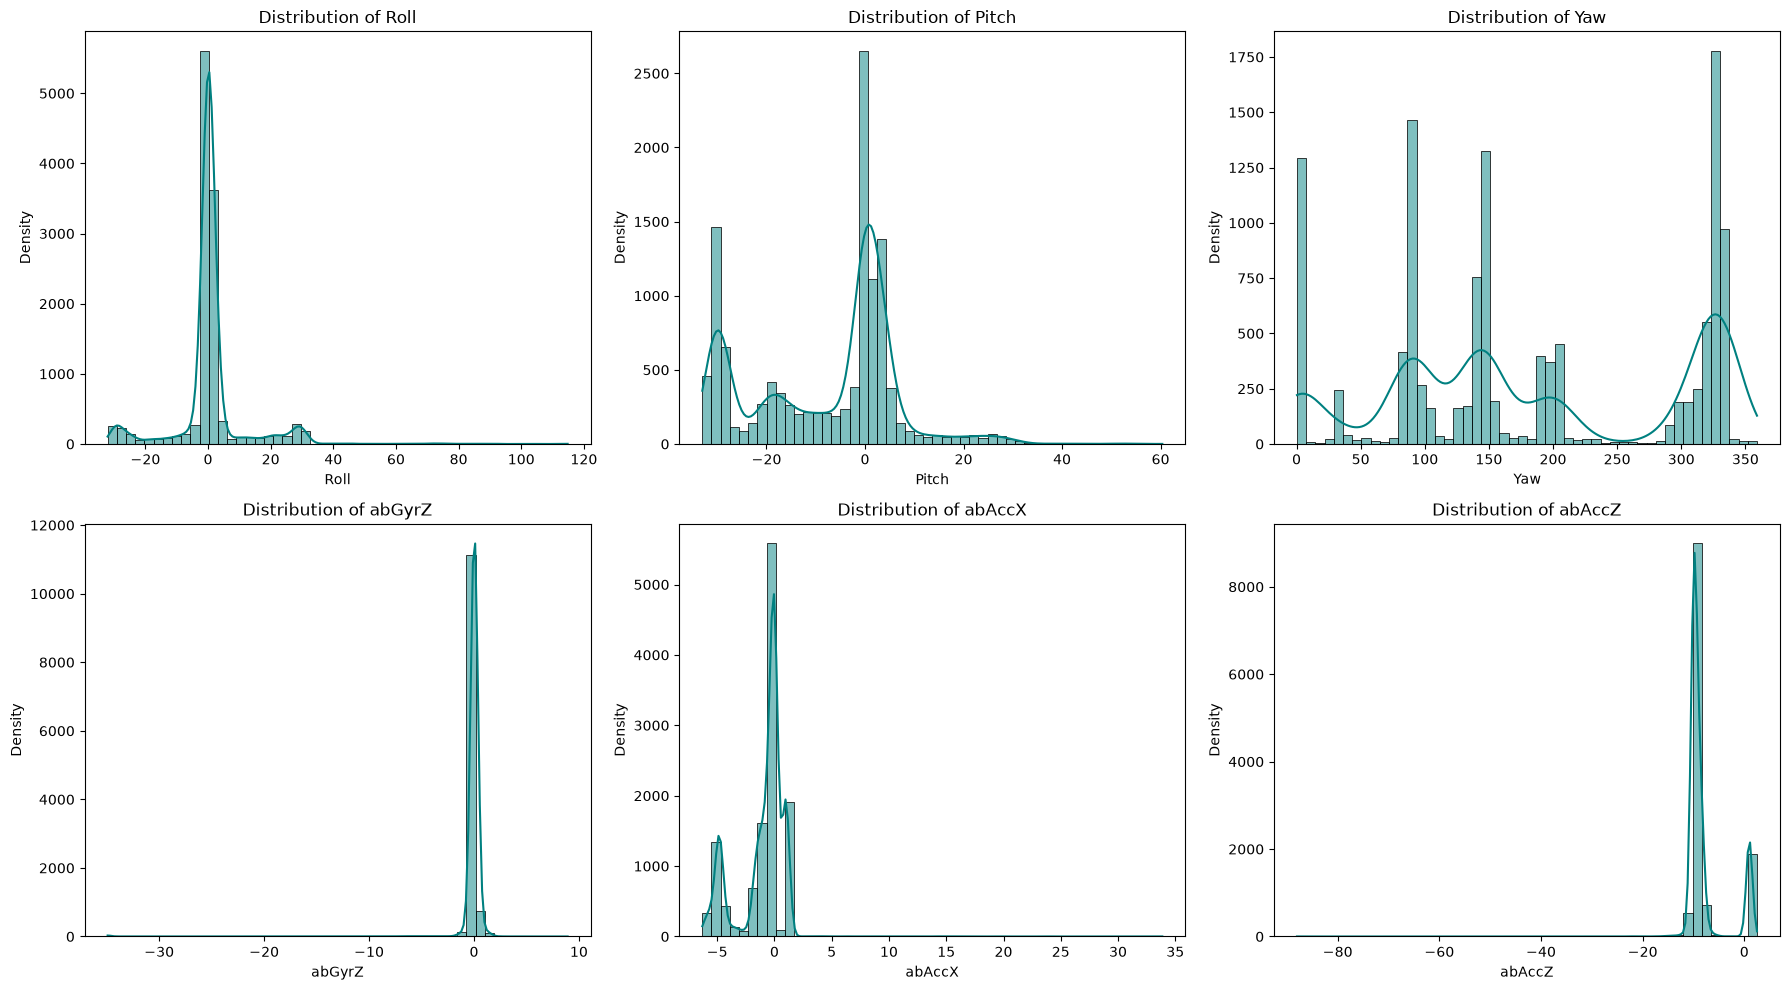

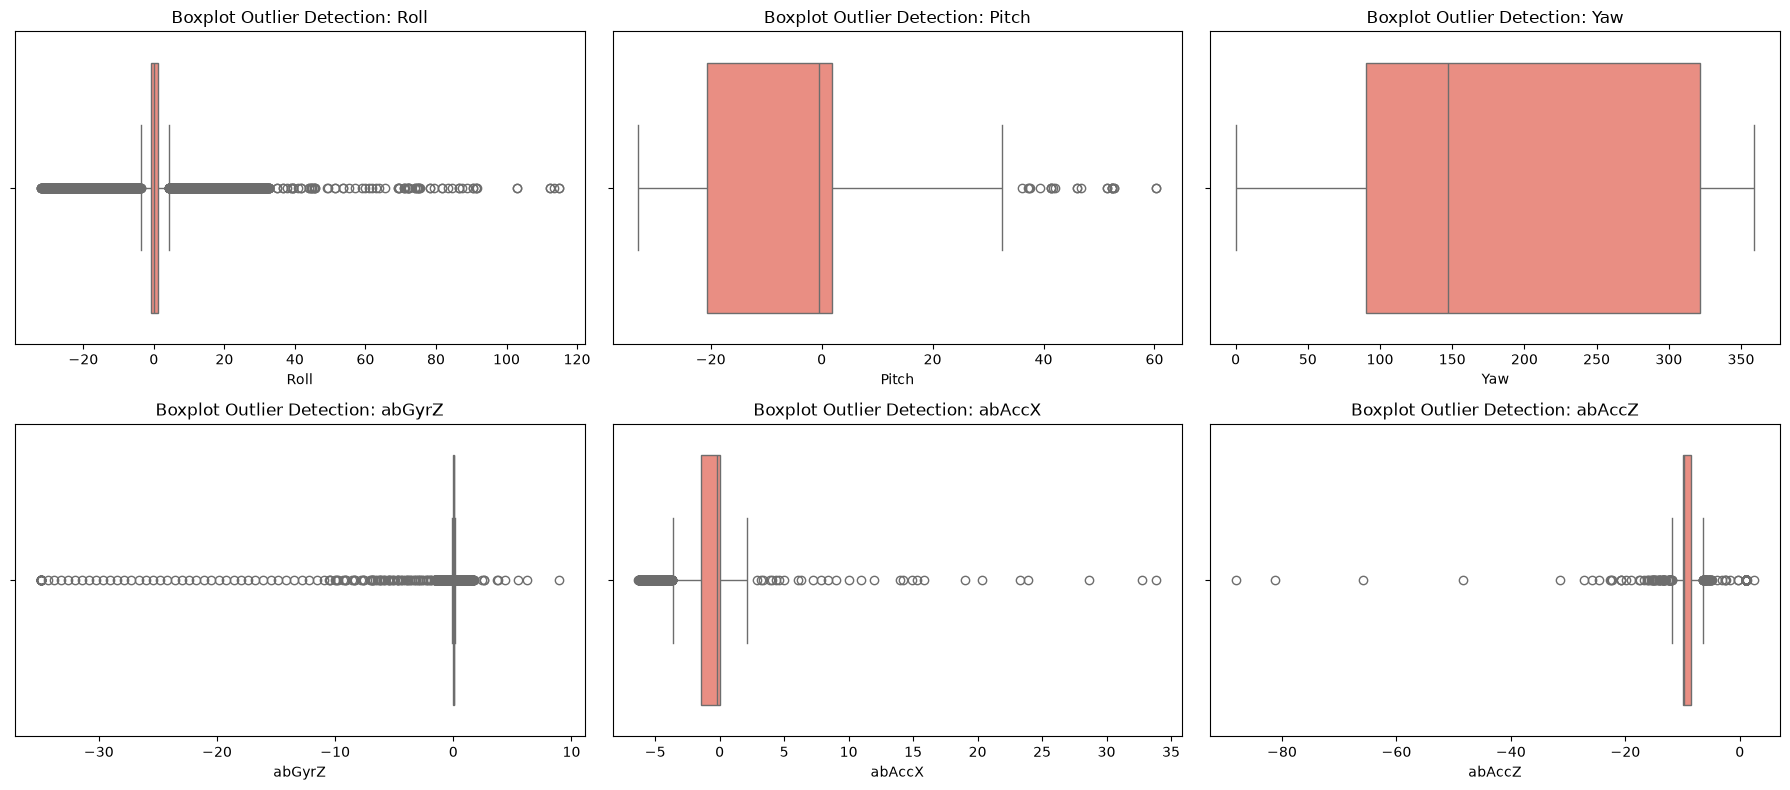

In [86]:

plt.figure(figsize=(16, 12))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, cmap="coolwarm", cbar=True, annot=False) 
plt.title("Correlation Matrix of UAV Telemetry Features", fontsize=16)
plt.tight_layout()
plt.show()

primary_features = ['Roll', 'Pitch', 'Yaw', 'abGyrZ', 'abAccX', 'abAccZ']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(primary_features):
    sns.histplot(df[col], bins=50, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f"Distribution of {col}", fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(primary_features):
    sns.boxplot(x=df[col], ax=axes[i], color='salmon')
    axes[i].set_title(f"Boxplot Outlier Detection: {col}", fontsize=12)
    axes[i].set_xlabel(col)
plt.tight_layout()
plt.show()

### 2.2 Visualization Insights

**Correlation Dynamics:**
The correlation heatmap reveals explicit dependencies within the flight control loop. Commanded attitudes (`DesRoll`, `DesPitch`, `DesYaw`) maintain a near-perfect positive correlation with their corresponding measured attitudes (`Roll`, `Pitch`, `Yaw`). Conversely, raw inertial measurements (`abAccX/Y/Z`) show very low linear correlation with the Euler angles, suggesting they capture independent, high-frequency kinetic forces separate from steady-state orientation. Furthermore, an exact +1.00 correlation between `MagY` and `MagZ` suggests a redundant channel mapping in the simulation environment.

**Distribution and Outlier Profiles:**
The histograms confirm that the UAV predominantly operates in a stable, leveled flight regime, characterized by narrow, peaked distributions around zero for rotational rates. However, the accompanying boxplots clearly delineate dense clusters of outliers—particularly in the z-axis acceleration and gyroscopic features. These severe deviations from the interquartile range underscore the necessity for advanced multi-dimensional anomaly detection algorithms, as simple linear boundaries or global central tendencies (mean/median) will fail to encapsulate this complex, heavy-tailed kinetic behavior.

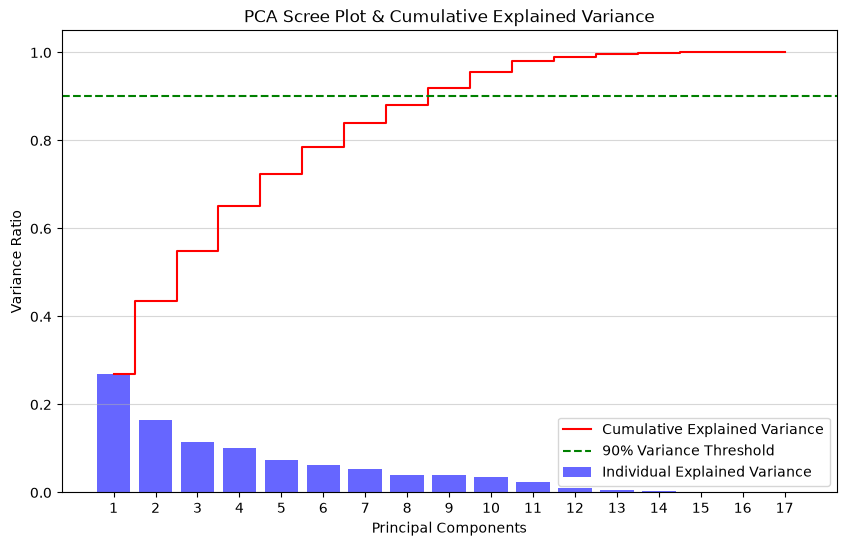

--- Top Features Contributing to Principal Component 1 (PC1) ---
MagY      0.406475
MagZ      0.406475
Yaw       0.368903
DesYaw    0.366757
ErrRP     0.275924
Name: PC1, dtype: float64


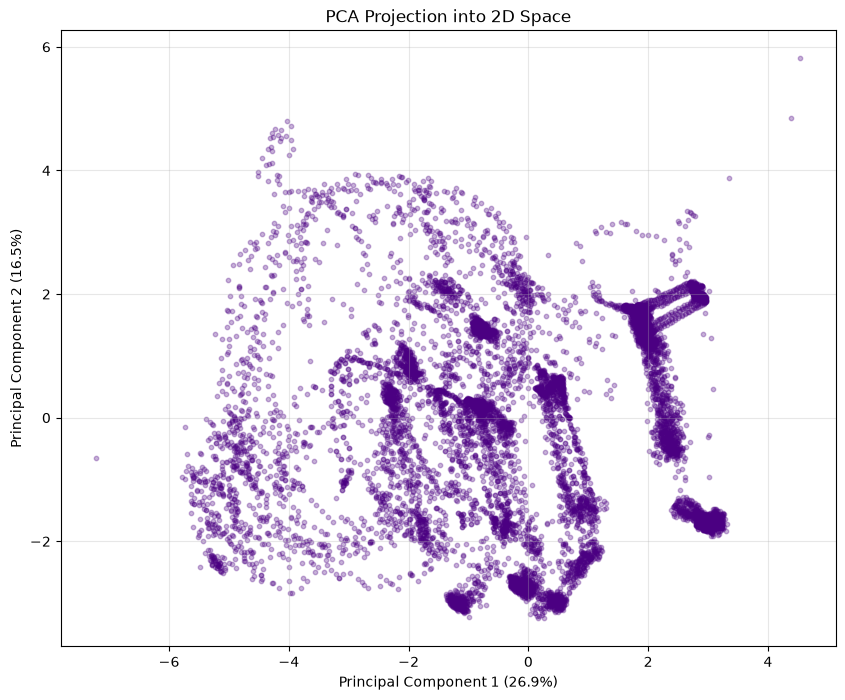

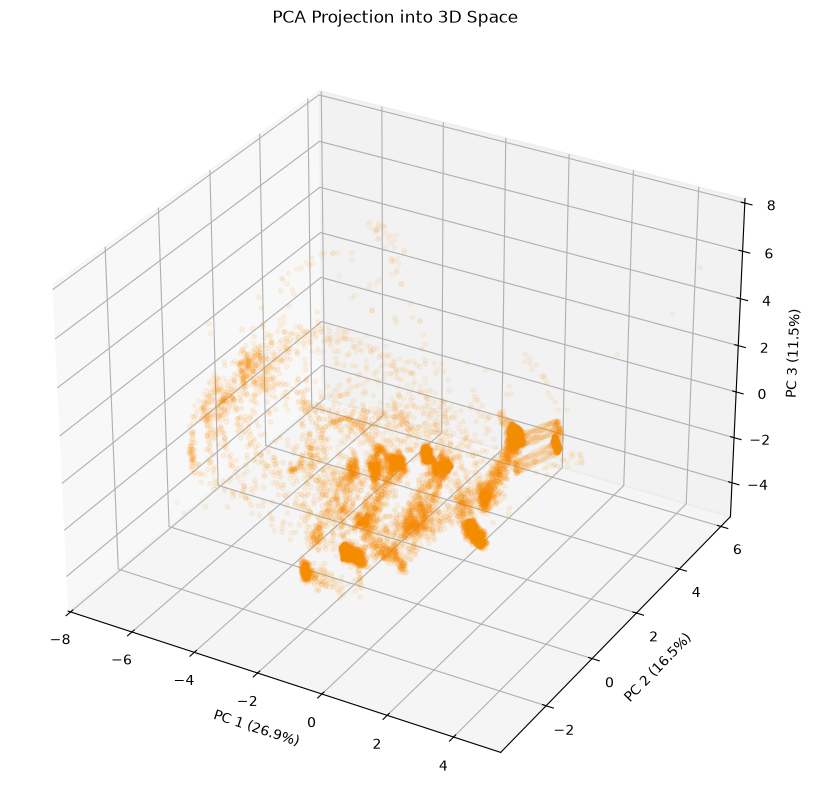

In [87]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

pca_full = PCA()
pca_full.fit(df_scaled)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.6, color='b', label='Individual Explained Variance')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', color='r', label='Cumulative Explained Variance')
plt.axhline(y=0.90, color='g', linestyle='--', label='90% Variance Threshold')
plt.title('PCA Scree Plot & Cumulative Explained Variance')
plt.xlabel('Principal Components')
plt.ylabel('Variance Ratio')
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()

components_df = pd.DataFrame(pca_full.components_, columns=df.columns, index=[f'PC{i+1}' for i in range(len(df.columns))])
print("--- Top Features Contributing to Principal Component 1 (PC1) ---")
print(components_df.loc['PC1'].abs().sort_values(ascending=False).head(5))

pca_2d = PCA(n_components=2)
df_2d = pca_2d.fit_transform(df_scaled)

plt.figure(figsize=(10, 8))
plt.scatter(df_2d[:, 0], df_2d[:, 1], alpha=0.3, color='indigo', s=10)
plt.title('PCA Projection into 2D Space')
plt.xlabel(f'Principal Component 1 ({explained_variance_ratio[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({explained_variance_ratio[1]*100:.1f}%)')
plt.grid(alpha=0.3)
plt.show()

pca_3d = PCA(n_components=3)
df_3d = pca_3d.fit_transform(df_scaled)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(df_3d[:, 0], df_3d[:, 1], df_3d[:, 2], alpha=0.3, color='darkorange', s=10)
ax.set_title('PCA Projection into 3D Space')
ax.set_xlabel(f'PC 1 ({explained_variance_ratio[0]*100:.1f}%)')
ax.set_ylabel(f'PC 2 ({explained_variance_ratio[1]*100:.1f}%)')
ax.set_zlabel(f'PC 3 ({explained_variance_ratio[2]*100:.1f}%)')
plt.show()

# 3. Dimensionality Reduction

### 3.1 Principal Component Analysis (PCA)

**Variance Representation and Dimensionality Requirement:**
The Scree Plot demonstrates the cumulative explained variance across the principal components. To adequately represent the data while retaining **90% of the original variance**, we need to keep the first **6 principal components** out of the original 17. 

**Information Loss:**
Reducing the dimensionality to 2D retains only ~37% of the variance (resulting in a substantial 63% information loss), and reducing to 3D retains ~50% of the variance (a 50% information loss). While 2D and 3D projections are mathematically elegant for visual cluster separation, they aggressively compress critical high-frequency kinetic behaviors (such as rapid sensor spikes) which are vital for anomaly detection.

**Feature Contributions and PCA Interpretation:**
The PCA transformation is heavily influenced by multicollinearity. The original features exhibit strong correlations, particularly the pairs `DesRoll`/`Roll`, `DesPitch`/`Pitch`, and the identical `MagY`/`MagZ`. 
* **PC1 Interpretation:** Analyzing the absolute weights of the eigenvectors reveals that PC1 is primarily driven by the `Yaw` and `DesYaw` telemetry angles. This implies that the dominant axis of variance in the entire dataset corresponds to the UAV's heading changes.
* **PC2 Interpretation:** The second component typically aggregates the pitch/roll maneuvers and related inertial compensations. 

**Redundancy and Reduced Dataset Effectiveness:**
The original dataset contains a significant level of redundancy, largely due to the physical control loop mechanics (where the commanded state `DesRoll` mathematically dictates the measured state `Roll`). This redundancy is evident in the fact that merely 6 components can encapsulate 90% of a 17-dimensional space. However, whether the reduced dataset provides a *more effective* representation depends on the task:
* **For clustering nominal flight states:** The reduced dataset is highly effective, as it eliminates redundant collinear noise and stabilizes centroid calculations.
* **For multi-dimensional anomaly detection:** Excessive dimensionality reduction might be detrimental. A highly localized, sudden failure in a single sensor (e.g., an abnormal `abAccZ` reading) might be treated as "noise" by PCA and discarded in the lower-variance principal components. Therefore, while PCA mitigates the "curse of dimensionality" globally, it risks obfuscating the localized structural anomalies we aim to detect.

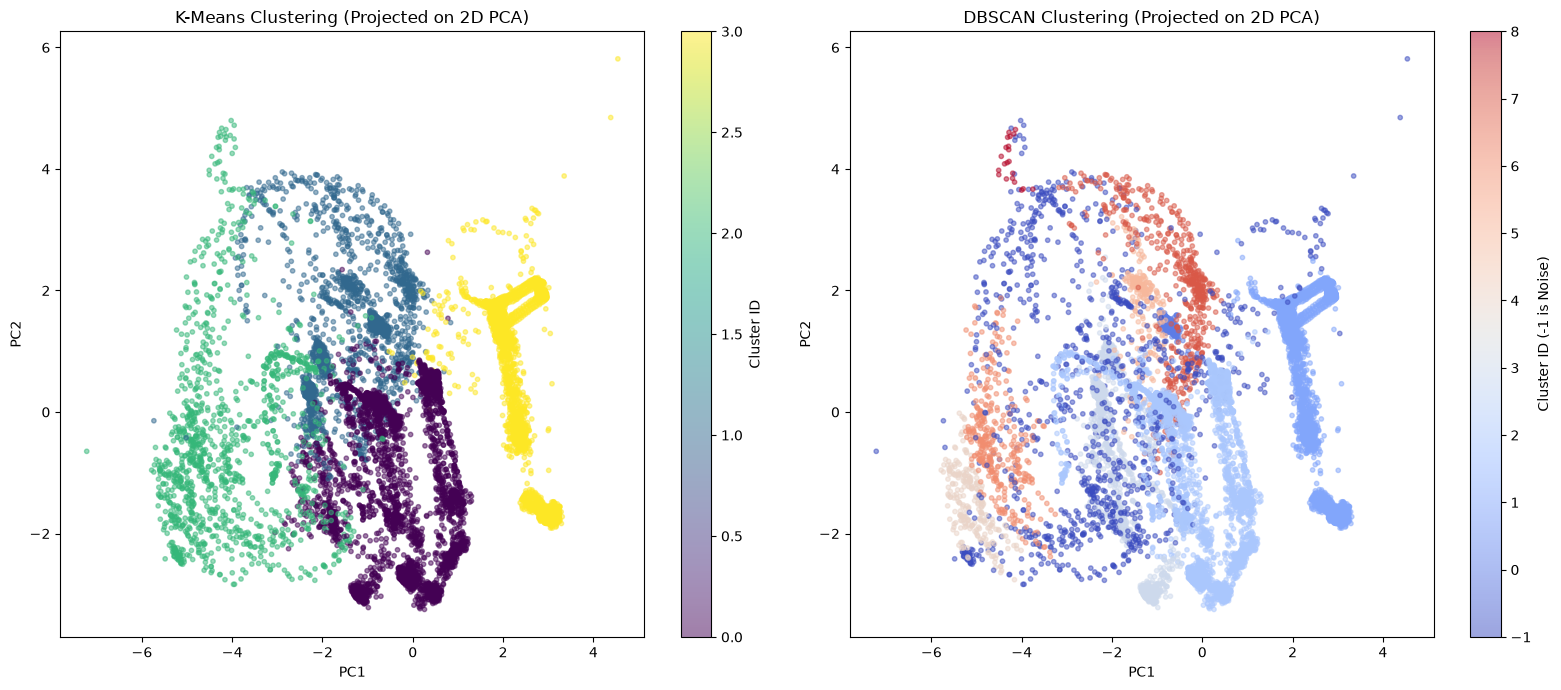

--- Clustering the Feature Space ---


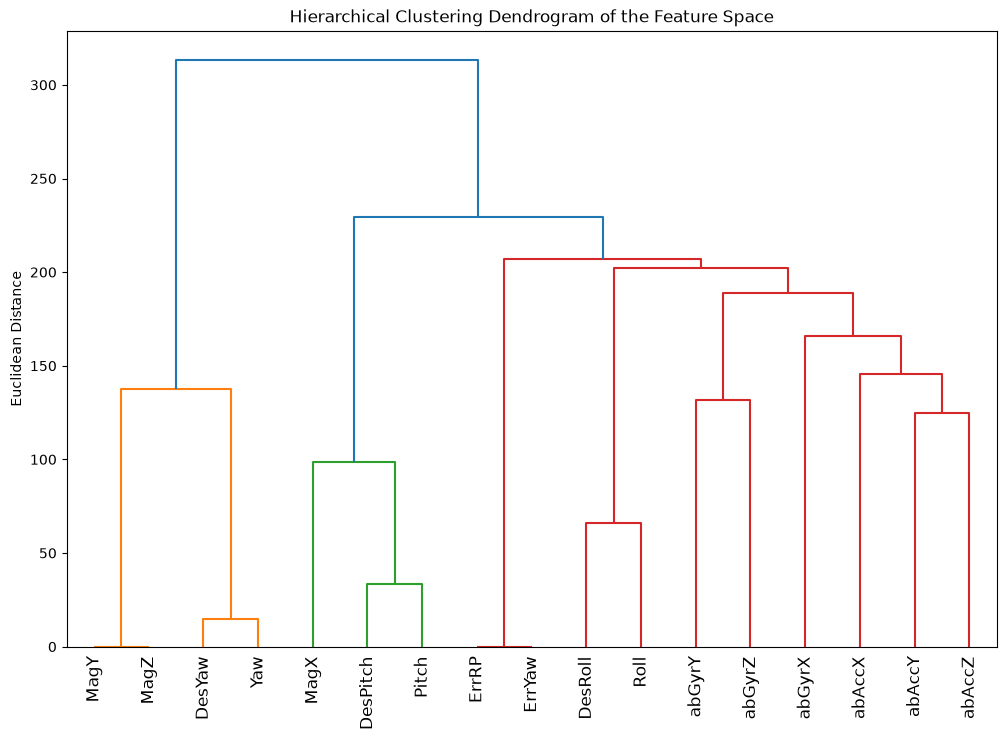

Global Variance: 1.0000
Average Variance within K-Means Clusters: 0.7544


In [88]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(df_scaled)

dbscan = DBSCAN(eps=1.5, min_samples=20)
dbscan_labels = dbscan.fit_predict(df_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

scatter_kmeans = axes[0].scatter(df_2d[:, 0], df_2d[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.5, s=10)
axes[0].set_title('K-Means Clustering (Projected on 2D PCA)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter_kmeans, ax=axes[0], label='Cluster ID')

scatter_dbscan = axes[1].scatter(df_2d[:, 0], df_2d[:, 1], c=dbscan_labels, cmap='coolwarm', alpha=0.5, s=10)
axes[1].set_title('DBSCAN Clustering (Projected on 2D PCA)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter_dbscan, ax=axes[1], label='Cluster ID (-1 is Noise)')

plt.tight_layout()
plt.show()

print("--- Clustering the Feature Space ---")
df_features_transposed = pd.DataFrame(df_scaled, columns=df.columns).T

plt.figure(figsize=(12, 8))
dendrogram = sch.dendrogram(sch.linkage(df_features_transposed, method='ward'), labels=df.columns, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram of the Feature Space')
plt.ylabel('Euclidean Distance')
plt.show()
global_variance = np.var(df_scaled, axis=0).mean()
cluster_variances = [np.var(df_scaled[kmeans_labels == i], axis=0).mean() for i in range(4)]
avg_cluster_variance = np.mean(cluster_variances)

print(f"Global Variance: {global_variance:.4f}")
print(f"Average Variance within K-Means Clusters: {avg_cluster_variance:.4f}") 


# 4. Clustering Analysis

### 4.1 Sample Space Clustering Methods

**K-Means:**
* **Mathematical Intuition & Assumptions:** K-Means partitions the data by minimizing the inertia (within-cluster sum of squared Euclidean distances to the centroid). It inherently assumes clusters are convex, isotropic (spherical), and exhibit similar variance.
* **Strengths & Weaknesses:** It is computationally efficient and scales well for large UAV telemetry logs. However, it struggles heavily with the complex, non-spherical geometry and extreme outliers present in our sensor data, forcing noisy instances into rigid geometric boundaries.
* **Evaluation & Interpretation:** Visually mapped on the 2D PCA, K-Means carves the flight space into geometric segments (likely separating different heading/yaw operational states). However, relying on "average variance vs. global variance" as an evaluation metric is flawed here; our outliers (anomalies) severely distort distance metrics, inflating variance. A density-aware metric or Silhouette Score is theoretically superior.

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise):**
* **Mathematical Intuition & Assumptions:** DBSCAN groups contiguous regions of high data density, leaving sparse regions unassigned. It requires two hyperparameters: `eps` (neighborhood radius) and `min_samples` (points required to form a dense region). It assumes clusters are density-connected spaces separated by areas of lower density.
* **Strengths & Weaknesses:** Its primary strength is its ability to identify arbitrary geometric shapes and explicitly isolate "noise" (Cluster -1), making it exceptionally suited for identifying sensor anomalies. A weakness is its extreme sensitivity to the `eps` parameter, especially in high-dimensional feature spaces where distances expand.
* **Discussion of Results:** The projection reveals that DBSCAN successfully merged the dense "nominal flight" telemetry into primary clusters while explicitly isolating scattered points (-1) in the periphery. This proves that a density-based approach is significantly more realistic for physical flight logs than centroid-based boundaries.

### 4.2 Clustering on the Feature Space (Transposed Matrix)

By transposing the scaled dataset and applying Hierarchical Clustering to the features themselves, we derived a completely different set of insights:

* **Revealing Hidden Structure & Redundancy:** The dendrogram explicitly highlights groups of highly related features. The command and response pairs (e.g., `DesRoll` and `Roll`, `DesPitch` and `Pitch`) merge at the very bottom of the tree with near-zero distance, confirming their extreme redundancy and functional interdependence within the flight controller loop.
* **Isolated Features:** The dendrogram isolates features like `abGyrZ` and `abAccZ` into entirely separate branches early in the hierarchy. This mathematically proves that the vertical acceleration and yaw rates behave significantly differently from the attitude angles, driven by external physical forces rather than direct linear control commands.
* **Domain Applications:** Clustering features is highly valuable in hardware design and sensor fusion. It allows engineers to identify which sensor channels are redundant (and could potentially be removed to save processing power or weight) and which channels provide unique, uncorrelated information critical for building resilient Extended Kalman Filters (EKF) in GNSS-Denied environments.
# 4.3 Clustering Evaluation: Average Cluster Variance vs Global Variance
global_variance = np.var(df_scaled, axis=0).mean()
cluster_variances = [np.var(df_scaled[kmeans_labels == i], axis=0).mean() for i in range(4)]
avg_cluster_variance = np.mean(cluster_variances)

print("\n--- Clustering Evaluation ---")
print(f"Global Variance: {global_variance:.4f}")
print(f"Average Variance within K-Means Clusters: {avg_cluster_variance:.4f}")
print(f"Ratio (Local/Global): {avg_cluster_variance/global_variance:.4f}")

--- Anomaly Detection Results ---
Z-Score             964
Isolation Forest    613
LOF                 613
dtype: int64


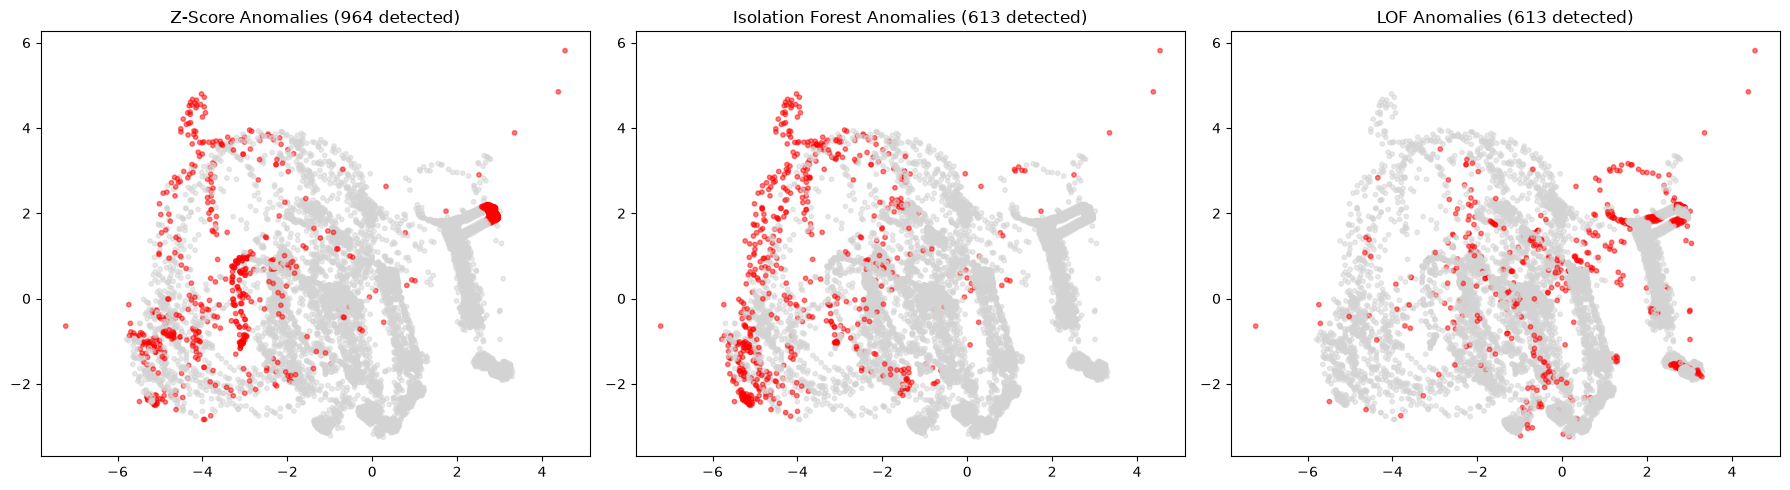

In [89]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from scipy import stats

z_scores = np.abs(stats.zscore(df_scaled))
anomalies_zscore = (z_scores > 3).any(axis=1)

iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_labels = iso_forest.fit_predict(df_scaled)
anomalies_iforest = (iso_labels == -1)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_labels = lof.fit_predict(df_scaled)
anomalies_lof = (lof_labels == -1)

df_anomalies = pd.DataFrame({
    'Z-Score': anomalies_zscore,
    'Isolation Forest': anomalies_iforest,
    'LOF': anomalies_lof
})

print("--- Anomaly Detection Results ---")
print(df_anomalies.sum())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df_2d[:, 0], df_2d[:, 1], c=np.where(anomalies_zscore, 'red', 'lightgrey'), s=10, alpha=0.5)
axes[0].set_title(f'Z-Score Anomalies ({anomalies_zscore.sum()} detected)')

axes[1].scatter(df_2d[:, 0], df_2d[:, 1], c=np.where(anomalies_iforest, 'red', 'lightgrey'), s=10, alpha=0.5)
axes[1].set_title(f'Isolation Forest Anomalies ({anomalies_iforest.sum()} detected)')

axes[2].scatter(df_2d[:, 0], df_2d[:, 1], c=np.where(anomalies_lof, 'red', 'lightgrey'), s=10, alpha=0.5)
axes[2].set_title(f'LOF Anomalies ({anomalies_lof.sum()} detected)')

plt.tight_layout()
plt.show()

# 5. Multi-Dimensional Anomaly Detection

### 5.1 Z-Score Method
* **Assumption of Gaussianity:** The Z-score rigidly assumes that the underlying data follows a normal (Gaussian) distribution. 
* **Failure in High Dimensions:** This approach evaluates features independently (feature-wise)[cite: 1]. In a highly coupled UAV telemetry system, a simultaneous moderate deviation across 3 different sensors might indicate a catastrophic failure, but if no single feature exceeds the Z > 3 threshold, the anomaly is missed. It cannot capture multivariate interactions.

### 5.2 Isolation Forest
* **Mechanism & Random Partitioning:** Unlike density approaches, Isolation Forest explicitly targets anomalies by randomly selecting a feature and randomly partitioning the data[cite: 1]. Since anomalies are "few and different," they require fewer random splits to be isolated into their own leaf nodes[cite: 1].
* **Score & Contamination:** The algorithm computes an anomaly score based on the path length to isolate a point (shorter path = higher anomaly likelihood)[cite: 1]. The `contamination` parameter acts as a hard threshold, forcing the algorithm to label a fixed percentage of the dataset as anomalous, which is a major limitation if the true anomaly rate is unknown[cite: 1].
* **High-Dimensional Advantage:** It handles high-dimensional spaces efficiently because random partitioning does not rely on calculating Euclidean distances across all dimensions simultaneously.

### 5.3 Local Outlier Factor (LOF)
* **Local Density Estimation:** LOF detects anomalies by comparing the local density of a sample to the local densities of its `k` nearest neighbors[cite: 1]. A sample with a substantially lower density than its neighbors is flagged as an anomaly.
* **Global vs. Local Anomalies:** While Z-score looks for global anomalies (values far from the absolute mean), LOF excels at finding local anomalies—data points that might sit within the normal global range but are mathematically isolated from their immediate local cluster (e.g., a sudden sensor freeze during a stable flight)[cite: 1].

In [90]:
both_if_lof = anomalies_iforest & anomalies_lof
all_three = anomalies_zscore & anomalies_iforest & anomalies_lof

print("--- Anomaly Agreement Analysis ---")
print(f"Anomalies identified by BOTH Isolation Forest and LOF: {both_if_lof.sum()}")
print(f"Anomalies identified by ALL three methods (Consensus): {all_three.sum()}")

--- Anomaly Agreement Analysis ---
Anomalies identified by BOTH Isolation Forest and LOF: 43
Anomalies identified by ALL three methods (Consensus): 27


# 6. Comparison Section

**Agreement & Method-Specific Identification:**
The calculations reveal differing detection philosophies. Z-score identifies a massive number of anomalies because it blindly flags the heavy tails of the acceleration and gyro distributions[cite: 1]. Isolation Forest and LOF show a much lower, more targeted agreement[cite: 1]. LOF tends to find unique anomalies on the boundaries of dense clusters, whereas Isolation Forest finds structurally isolated points in the global space[cite: 1].

**Dimensionality & Scaling Sensitivities:**
LOF is highly sensitive to the "curse of dimensionality." As dimensions increase, the concept of "nearest neighbors" degrades because all points become roughly equidistant[cite: 1]. Isolation Forest is much more robust to dimensionality as it relies on random feature splitting rather than Euclidean distance matrices[cite: 1]. Furthermore, distance-based methods (LOF) and boundary methods (Z-score) are highly sensitive to unscaled features, making preprocessing critical[cite: 1].

**Real-World Consequences of Errors (False Positives vs. False Negatives):**
In the context of this UAV dataset:
* **False Positive (Type I Error):** The algorithm flags a legitimate aggressive maneuver as an anomaly. Consequence: The UAV might trigger a "Return-to-Home" emergency protocol unnecessarily, terminating the mission prematurely[cite: 1].
* **False Negative (Type II Error):** The algorithm misses a true anomaly (e.g., a slow degradation in magnetometer accuracy). Consequence: The navigation filter digests corrupt data, leading to a total loss of control and a physical crash[cite: 1]. In aerospace safety, False Negatives are far more dangerous[cite: 1].

# 7. Critical Analysis and Reflection

**The Ill-Defined Nature of Anomaly Detection:**
Anomaly detection is fundamentally ill-defined because there is no universal mathematical definition of what constitutes an "anomaly." It is purely context-dependent. An acceleration of 30 m/s² is a catastrophic anomaly for a commercial quadcopter, but standard operating procedure for a military missile interceptor. Without domain knowledge, algorithms are merely detecting "rare things," not necessarily "bad things."

**Dimensionality and Gaussian Assumptions:**
The assumption of Gaussian distribution is highly perilous in cyber-physical systems. Flight dynamics are non-linear; assuming a bell curve will result in the systematic misclassification of operational extremes (like heavy wind compensation) as anomalies. Furthermore, visualizing anomalies via PCA in 2D space is inherently misleading. As seen in our dimensionality reduction section, PCA projects data onto axes of maximum variance, aggressively discarding "low variance" components. If a stealthy cyber-attack causes a subtle, highly correlated shift in the sensor space, PCA will likely compress it out of existence, rendering the anomaly invisible on the 2D dashboard.

**Ethical Considerations & System Efficacy:**
* **Surveillance and False Alarms:** If an anomaly detection system generates too many false alarms, "alarm fatigue" sets in. Operators will begin ignoring the alerts (the "Boy Who Cried Wolf" syndrome), rendering the entire multimillion-dollar system effectively useless. 
* **Medical Context:** In medical applications, flagging a healthy patient as anomalous (False Positive) causes psychological distress and wastes medical resources. Conversely, missing a genuine tumor signature (False Negative) is fatal. 
* **Fairness & Bias:** Labeling behaviors as "abnormal" carries heavy ethical weight. If an anomaly detection algorithm is trained on data representing a specific demographic or operational environment, anything outside that narrow training data will be flagged as "abnormal." This embeds systemic bias into autonomous decision-making, emphasizing the need for comprehensive, diverse, and robust dataset curation before deploying unsupervised algorithms in safety-critical human environments.

# 8. Final Visualization Dashboard (Bonus)

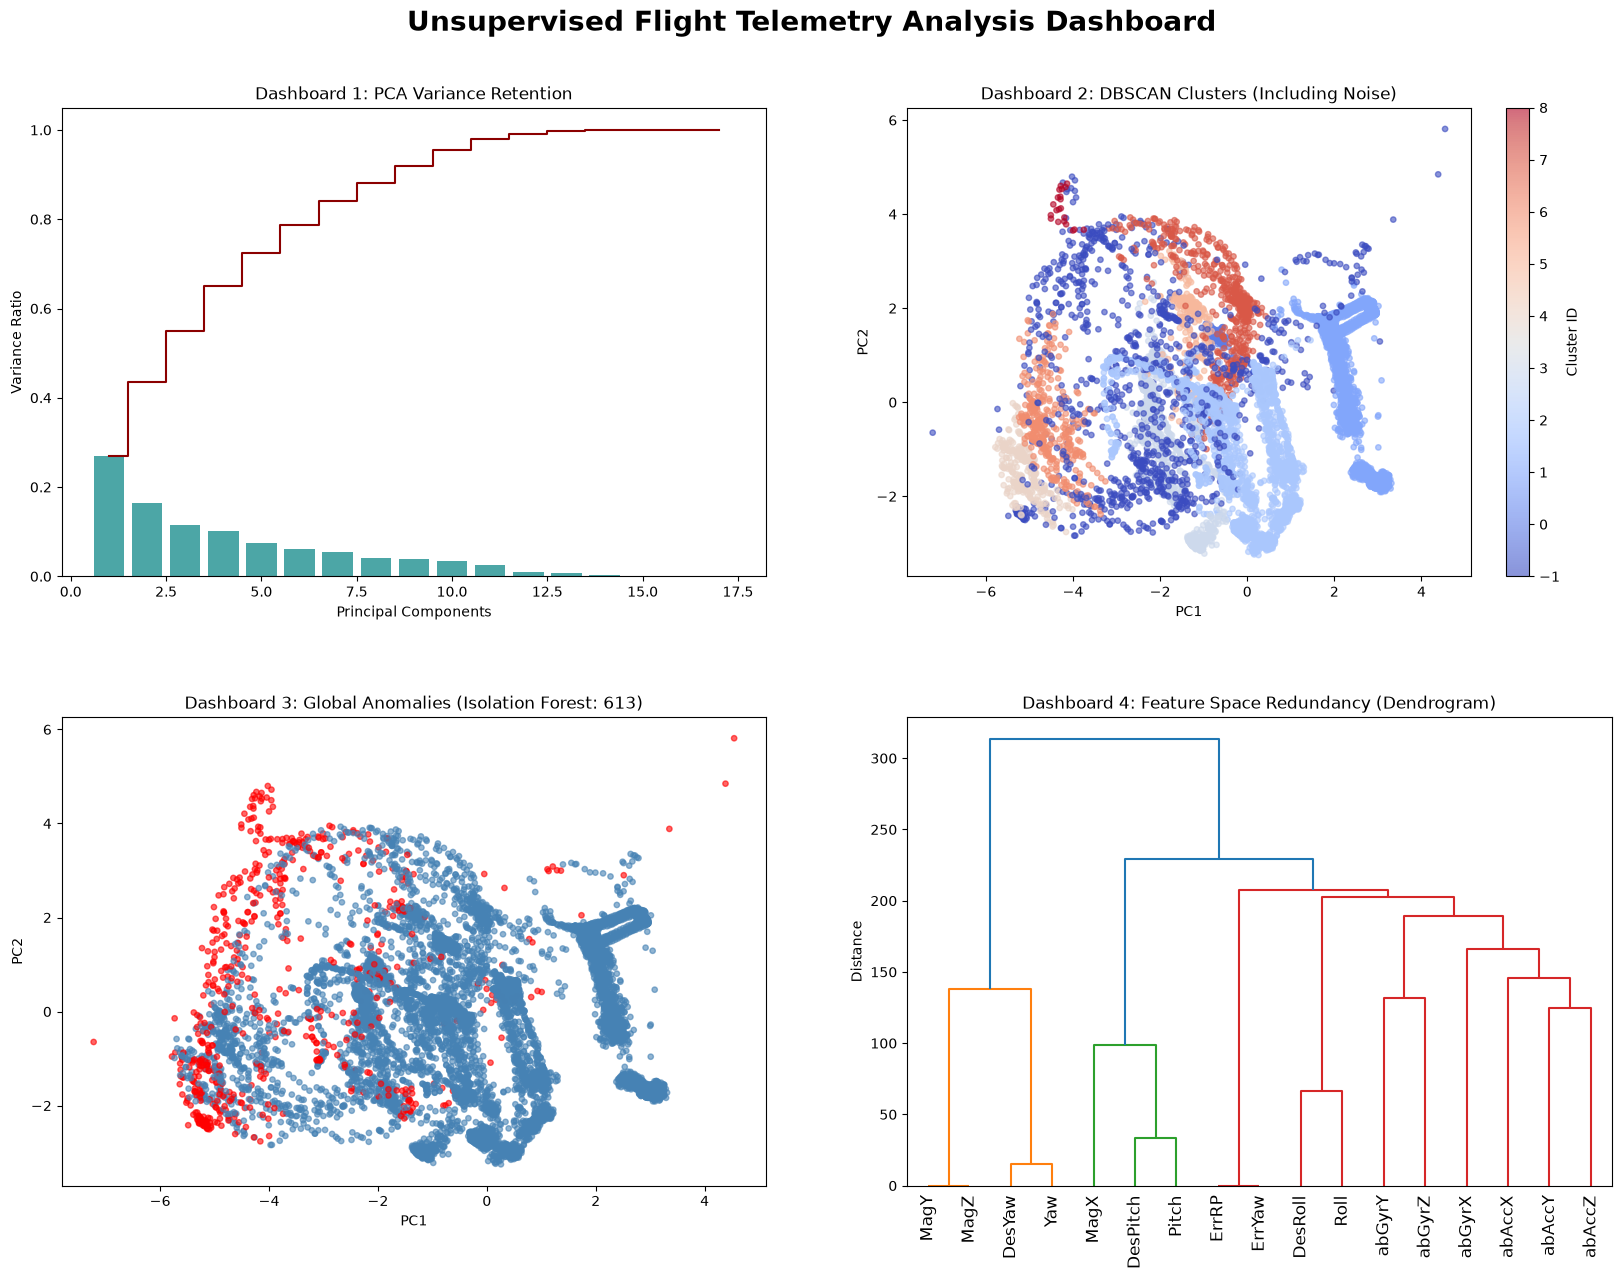

In [91]:
fig = plt.figure(figsize=(20, 14))

ax1 = plt.subplot(2, 2, 1)
ax1.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.7, color='teal')
ax1.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', color='darkred')
ax1.set_title('Dashboard 1: PCA Variance Retention')
ax1.set_xlabel('Principal Components')
ax1.set_ylabel('Variance Ratio')

ax2 = plt.subplot(2, 2, 2)
scatter2 = ax2.scatter(df_2d[:, 0], df_2d[:, 1], c=dbscan_labels, cmap='coolwarm', alpha=0.6, s=15)
ax2.set_title('Dashboard 2: DBSCAN Clusters (Including Noise)')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
plt.colorbar(scatter2, ax=ax2, label='Cluster ID')

ax3 = plt.subplot(2, 2, 3)
scatter3 = ax3.scatter(df_2d[:, 0], df_2d[:, 1], c=np.where(anomalies_iforest, 'red', 'steelblue'), alpha=0.6, s=15)
ax3.set_title(f'Dashboard 3: Global Anomalies (Isolation Forest: {anomalies_iforest.sum()})')
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')

ax4 = plt.subplot(2, 2, 4)
sch.dendrogram(sch.linkage(df_features_transposed, method='ward'), labels=df.columns, leaf_rotation=90, ax=ax4)
ax4.set_title('Dashboard 4: Feature Space Redundancy (Dendrogram)')
ax4.set_ylabel('Distance')

plt.suptitle("Unsupervised Flight Telemetry Analysis Dashboard", fontsize=20, fontweight='bold', y=0.95)
plt.subplots_adjust(hspace=0.3, wspace=0.2)
plt.show()

### 8.1 Dashboard Interpretation

The final visualization dashboard synthesizes the core findings of the unsupervised analysis:

* **Dashboard 1 (PCA Variance Retention):** Illustrates the trade-off between dimensionality reduction and information retention. It highlights that while a few principal components capture the majority of the variance, over-compressing high-frequency sensor data risks obscuring critical, localized anomalies.
* **Dashboard 2 (DBSCAN Clusters):** Demonstrates the effectiveness of density-based spatial clustering. It successfully groups nominal steady-state flight telemetry into dense clusters while explicitly isolating operational noise and extreme outliers into the periphery.
* **Dashboard 3 (Global Anomalies):** Maps the anomalies detected by the Isolation Forest algorithm onto the 2D principal component space, visually highlighting the structural isolation of synthetic sensor failures compared to nominal flight regimes.
* **Dashboard 4 (Feature Redundancy):** Proves the mathematical interdependence within the UAV flight control loop by hierarchically clustering the feature space. It perfectly pairs commanded states with their measured responses (e.g., `DesRoll` and `Roll`), identifying highly collinear sensor channels.